CUSTOM BANK MARKETING DATASET
   age         job  balance housing_loan  previous_contact purchase
0   25     student     1000           no                 0       no
1   34       admin     2500          yes                 2      yes
2   45  management     5000          yes                 3      yes
3   52     retired     7000           no                 5      yes
4   23     student     1200           no                 0       no
5   40  technician     3000          yes                 1      yes
6   60     retired     9000           no                 6      yes
7   48  management     6500          yes                 4      yes
8   33       admin     2700          yes                 2       no
9   29  technician     3200           no                 1      yes

Training data size: 8
Testing data size : 2

MODEL PERFORMANCE
Accuracy Score: 50.00%


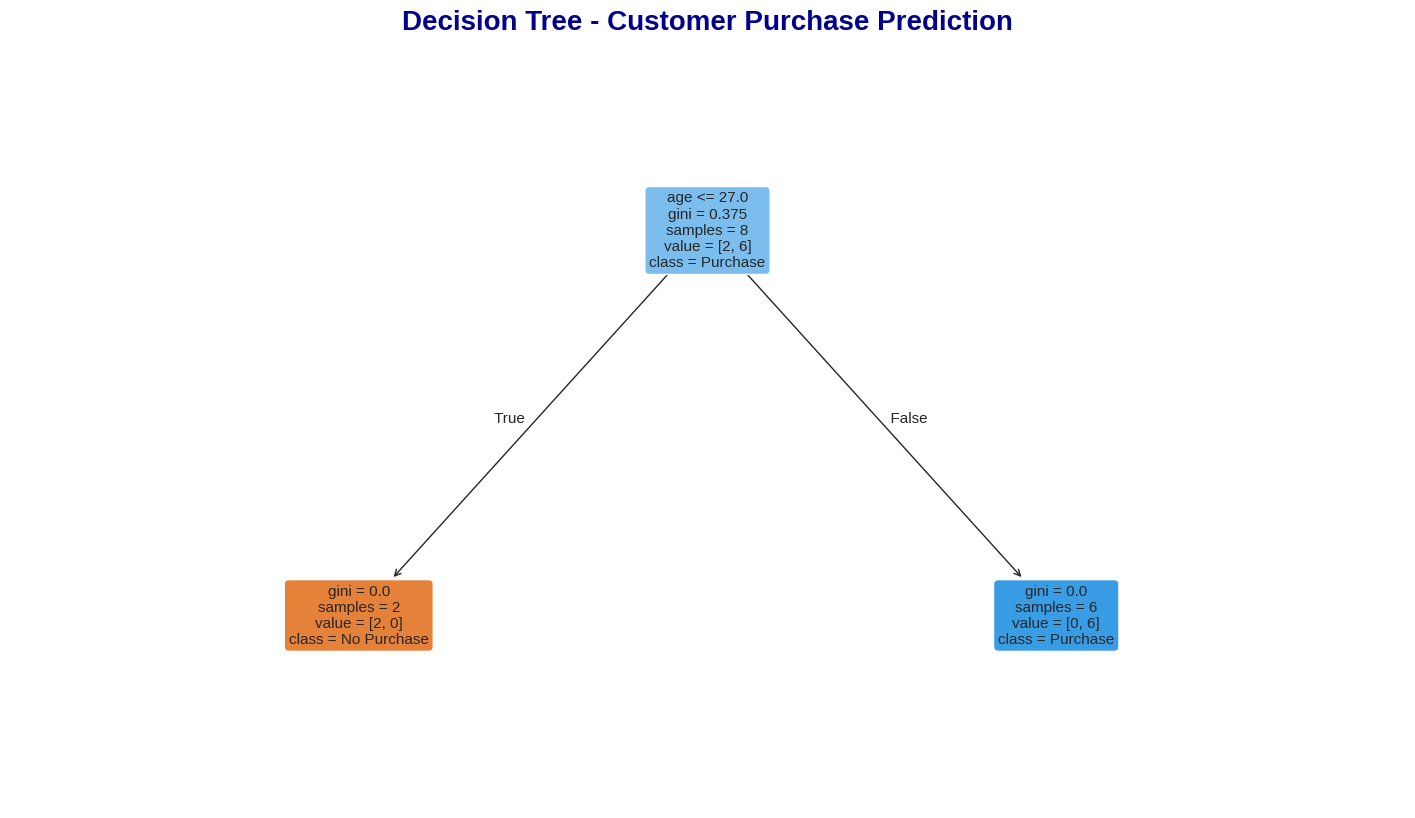

In [55]:
# ============================================
# BANK MARKETING - DECISION TREE CLASSIFIER
# ============================================

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# ============================================
# 1. CREATE CUSTOM DATASET
# ============================================

data = {
    'age': [25, 34, 45, 52, 23, 40, 60, 48, 33, 29],
    'job': ['student', 'admin', 'management', 'retired',
            'student', 'technician', 'retired', 'management',
            'admin', 'technician'],
    'balance': [1000, 2500, 5000, 7000, 1200,
                3000, 9000, 6500, 2700, 3200],
    'housing_loan': ['no', 'yes', 'yes', 'no',
                     'no', 'yes', 'no', 'yes',
                     'yes', 'no'],
    'previous_contact': [0, 2, 3, 5, 0, 1, 6, 4, 2, 1],
    'purchase': ['no', 'yes', 'yes', 'yes',
                 'no', 'yes', 'yes', 'yes',
                 'no', 'yes']
}

bank_df = pd.DataFrame(data)

print("=" * 60)
print("CUSTOM BANK MARKETING DATASET")
print("=" * 60)

print(bank_df)

# ============================================
# 2. DATA PREPROCESSING
# ============================================

# Convert text columns into numbers
encoder = LabelEncoder()

bank_df['job'] = encoder.fit_transform(bank_df['job'])
bank_df['housing_loan'] = encoder.fit_transform(bank_df['housing_loan'])
bank_df['purchase'] = encoder.fit_transform(bank_df['purchase'])

# Features and target
X = bank_df.drop('purchase', axis=1)
y = bank_df['purchase']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining data size:", X_train.shape[0])
print("Testing data size :", X_test.shape[0])

# ============================================
# 3. BUILD DECISION TREE MODEL
# ============================================

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"Accuracy Score: {accuracy * 100:.2f}%")

# ============================================
# 4. VISUALIZE DECISION TREE
# ============================================

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No Purchase', 'Purchase'],
    filled=True,
    rounded=True,
    fontsize=11
)

plt.title(
    "Decision Tree - Customer Purchase Prediction",
    fontsize=20,
    fontweight='bold',
    color='darkblue'
)

plt.show()